# AACNN-ViT Lung Cancer Diagnosis
Multi-modal deep learning for lung cancer classification using CNN + Vision Transformer (ViT).

## Key Features:
- ✓ Adaptive fusion of CNN and ViT features
- ✓ Comprehensive evaluation metrics (Confusion Matrix, ROC-AUC, Precision/Recall/F1)
- ✓ Grad-CAM visualization for model explainability
- ✓ Structured risk assessment with clinical terminology
- ✓ Detailed diagnostic reporting

## Required Dependencies:
```bash
pip install tensorflow torch transformers scikit-learn matplotlib seaborn numpy opencv-python
```

In [12]:
import sys
!"{sys.executable}" -m pip install torch torchvision torchaudio 


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow" 
import math, random
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import keras
from keras import layers, regularizers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight

# PyTorch ViT for robust feature extraction (fixes TF safetensors error)
import torch
from transformers import ViTImageProcessor, ViTModel

c:\Users\Bilal\OneDrive\Desktop\Lung Cancer\AACNN-ViT\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached torch-2.10.0-cp311-cp311-win_amd64.whl.metadata (31 kB)
  Using cached torchvision-0.25.0-cp311-cp311-win_amd64.whl.metadata (5.4 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached fsspec-2026.2.0-py3-none-any.whl.metadata (10 kB)
  Using cached tokenizers-0.22.2-cp39-abi3-win_amd64.whl.metadata (7.4 kB)
  Using cached safetensors-0.7.0-cp38-abi3-win_amd64.whl.metadata (4.2 kB)
  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached anyio-4.12.1-py3-none-any.whl.metadata (4.3 kB)
  Using cached httpcore-1.0.9-py3-none-any.whl.metadata (21 kB)
  Using cached h11-0.16.0-py3-none-any.whl.metadata (8.3 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
  Using cached click-8.3.1-py3-none-any.whl.metadata (2.6 kB)
  Using cached shellingham-1.5.4-py2.py3-none-any.whl.metadata (3.5 kB

In [14]:
# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [15]:
# If running in Colab, optionally mount Drive
try:
    from google.colab import drive  # type: ignore
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB:
    drive.mount("/content/drive")


In [16]:
BASE_DIR = r"C:\Users\Bilal\OneDrive\Desktop\Lung Cancer\AACNN-ViT\datasets"
CLASS_DIRS = ["Benign cases", "Malignant cases", "Normal cases"]
NUM_CLASSES = len(CLASS_DIRS)

IMG_SIZE = (512, 512)
VIT_INPUT_SIZE = (224, 224)
FEATURE_DIM = 768

BATCH_SIZE = 8

# Training budgets (main AACNN adaptive gets more budget on purpose)
EPOCHS_CNN = 15
EPOCHS_VIT = 15
EPOCHS_CNNVIT = 15

EPOCHS_ADAPT_STAGE_A = 10
EPOCHS_ADAPT_STAGE_B = 20

EPOCHS_NOADAPT_STAGE_A = 8
EPOCHS_NOADAPT_STAGE_B = 12

UNFREEZE_LAST_N = 60

# MixUp: apply only to main adaptive AACNN if desired
ADAPT_MIXUP_ALPHA = 0.20
NOADAPT_MIXUP_ALPHA = 0.00

VIT_MODEL_NAME = "google/vit-base-patch16-224-in21k"

TRAIN_FEATURES_PATH = os.path.join(BASE_DIR, "train_vit_features.npy")
VAL_FEATURES_PATH   = os.path.join(BASE_DIR, "val_vit_features.npy")

print("BASE_DIR:", BASE_DIR)
print("Classes:", CLASS_DIRS)

BASE_DIR: C:\Users\Bilal\OneDrive\Desktop\Lung Cancer\AACNN-ViT\datasets
Classes: ['Benign cases', 'Malignant cases', 'Normal cases']


In [ ]:
# Creates: X_train, X_val, y_train_int, y_val_int, y_train_oh, y_val_oh
import os
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split

SEED = 42

BASE_DIR = r"C:\Users\Bilal\OneDrive\Desktop\Lung Cancer\AACNN-ViT\datasets"  # change to yours
CLASS_DIRS = ["Benign cases", "Malignant cases", "Normal cases"]
NUM_CLASSES = len(CLASS_DIRS)
TRAIN_SIZE = 0.70

print("BASE_DIR exists?", os.path.isdir(BASE_DIR))
print("Inside BASE_DIR:", os.listdir(BASE_DIR))

def load_paths_and_labels(base_dir, class_dirs):
    paths, y_int = [], []
    for ci, cname in enumerate(class_dirs):
        cdir = os.path.join(base_dir, cname)
        if not os.path.isdir(cdir):
            raise FileNotFoundError(f"Missing class folder: {cdir}")
        for root, _, files in os.walk(cdir):
            for f in files:
                if f.lower().endswith((".png",".jpg",".jpeg",".bmp",".tif",".tiff",".webp")):
                    paths.append(os.path.join(root, f))
                    y_int.append(ci)
    return np.array(paths), np.array(y_int, dtype=np.int32)

all_paths, all_y_int = load_paths_and_labels(BASE_DIR, CLASS_DIRS)

X_train, X_val, y_train_int, y_val_int = train_test_split(
    all_paths, all_y_int,
    train_size=TRAIN_SIZE,
    stratify=all_y_int,
    random_state=SEED
)

y_train_oh = tf.keras.utils.to_categorical(y_train_int, NUM_CLASSES)
y_val_oh   = tf.keras.utils.to_categorical(y_val_int,   NUM_CLASSES)

print("Train:", X_train.shape, y_train_oh.shape)
print("Val:",   X_val.shape,   y_val_oh.shape)

BASE_DIR exists? True
Inside BASE_DIR: ['Benign cases', 'IQ-OTH_NCCD lung cancer dataset.txt', 'Malignant cases', 'Normal cases', 'train_vit_features.npy', 'val_vit_features.npy']
Train: (767,) (767, 3)
Val: (330,) (330, 3)


NameError: name 'train_generator' is not defined

## ViT CLS feature extraction

In [18]:
def extract_vit_features(image_paths, save_path, batch_size=BATCH_SIZE):
    if os.path.exists(save_path):
        feats = np.load(save_path, allow_pickle=True)
        if feats.shape[0] == len(image_paths):
            print(f"Loaded cached ViT features: {save_path} | {feats.shape}")
            return feats
        print("[WARN] Cache mismatch. Recomputing...")

    device = "cuda" if torch.cuda.is_available() else "cpu"
    print("ViT extraction device:", device)

    processor = ViTImageProcessor.from_pretrained(VIT_MODEL_NAME)
    vit = ViTModel.from_pretrained(VIT_MODEL_NAME).to(device)
    vit.eval()

    feats_list = []
    for start in range(0, len(image_paths), batch_size):
        batch_paths = image_paths[start:start + batch_size]
        batch_imgs = []
        for p in batch_paths:
            img = tf.keras.preprocessing.image.load_img(p, target_size=VIT_INPUT_SIZE)
            arr = tf.keras.preprocessing.image.img_to_array(img)  # 0..255
            batch_imgs.append(arr)

        inputs = processor(images=np.array(batch_imgs), return_tensors="pt")
        inputs = {k: v.to(device) for k, v in inputs.items()}

        with torch.no_grad():
            out = vit(**inputs)
            cls = out.last_hidden_state[:, 0, :]  # [B,768]
            feats_list.append(cls.cpu().numpy().astype(np.float32))

    feats = np.concatenate(feats_list, axis=0).astype(np.float32)
    np.save(save_path, feats)
    print(f"Saved ViT features: {save_path} | {feats.shape}")
    return feats

train_features = extract_vit_features(X_train, TRAIN_FEATURES_PATH)
val_features   = extract_vit_features(X_val,   VAL_FEATURES_PATH)

print("train_features:", train_features.shape)
print("val_features:", val_features.shape)


Loaded cached ViT features: C:\Users\Bilal\OneDrive\Desktop\Lung Cancer\AACNN-ViT\datasets\train_vit_features.npy | (767, 768)
Loaded cached ViT features: C:\Users\Bilal\OneDrive\Desktop\Lung Cancer\AACNN-ViT\datasets\val_vit_features.npy | (330, 768)
train_features: (767, 768)
val_features: (330, 768)


## Image loaders + Sequences (CNN, ViT-only, Fusion)

In [19]:
train_datagen = ImageDataGenerator(
    rotation_range=25,
    width_shift_range=0.20,
    height_shift_range=0.20,
    shear_range=0.15,
    zoom_range=0.20,
    horizontal_flip=True,
    brightness_range=[0.85, 1.15],
    channel_shift_range=15
)
val_datagen = ImageDataGenerator()

def load_img_01(path, augment=False):
    img = tf.keras.preprocessing.image.load_img(path, target_size=IMG_SIZE)
    arr = tf.keras.preprocessing.image.img_to_array(img)
    if augment:
        arr = train_datagen.random_transform(arr)
    return (arr / 255.0).astype(np.float32)



In [20]:
class CNNSequence(tf.keras.utils.Sequence):
    def __init__(self, paths, y_oh, bs, shuffle=True, augment=False, seed=SEED):
        self.paths = list(paths)
        self.y = np.asarray(y_oh, dtype=np.float32)
        self.bs = bs
        self.shuffle = shuffle
        self.augment = augment
        self.rng = np.random.default_rng(seed)
        self.idxs = np.arange(len(self.paths))
        self.on_epoch_end()

    def __len__(self):
        return math.ceil(len(self.paths) / self.bs)

    def on_epoch_end(self):
        if self.shuffle:
            self.rng.shuffle(self.idxs)

    def __getitem__(self, i):
        bi = self.idxs[i*self.bs:(i+1)*self.bs]
        bx = np.stack([load_img_01(self.paths[k], augment=self.augment) for k in bi], axis=0)
        by = self.y[bi]
        # IMPORTANT: bx is a numpy array (NOT a list)
        return bx, by


class ViTSequence(tf.keras.utils.Sequence):
    def __init__(self, vit_feats, y_oh, bs, shuffle=True, seed=SEED):
        self.vit = np.asarray(vit_feats, dtype=np.float32)
        self.y = np.asarray(y_oh, dtype=np.float32)
        self.bs = bs
        self.shuffle = shuffle
        self.rng = np.random.default_rng(seed)
        self.idxs = np.arange(len(self.vit))
        self.on_epoch_end()

    def __len__(self):
        return math.ceil(len(self.vit) / self.bs)

    def on_epoch_end(self):
        if self.shuffle:
            self.rng.shuffle(self.idxs)

    def __getitem__(self, i):
        bi = self.idxs[i*self.bs:(i+1)*self.bs]
        # IMPORTANT: returns (array, array), no lists
        return self.vit[bi], self.y[bi]


class FusionSequence(tf.keras.utils.Sequence):
    def __init__(self, paths, y_oh, vit_feats, bs,
                 shuffle=True, augment=False, mixup_alpha=0.0, seed=SEED):
        self.paths = list(paths)
        self.y = np.asarray(y_oh, dtype=np.float32)
        self.vit = np.asarray(vit_feats, dtype=np.float32)
        self.bs = bs
        self.shuffle = shuffle
        self.augment = augment
        self.mixup_alpha = float(mixup_alpha)
        self.rng = np.random.default_rng(seed)
        self.idxs = np.arange(len(self.paths))
        self.on_epoch_end()

    def __len__(self):
        return math.ceil(len(self.paths) / self.bs)

    def on_epoch_end(self):
        if self.shuffle:
            self.rng.shuffle(self.idxs)

    def __getitem__(self, i):
        bi = self.idxs[i*self.bs:(i+1)*self.bs]
        bx_paths = [self.paths[k] for k in bi]

        bx_img = np.stack([load_img_01(p, augment=self.augment) for p in bx_paths], axis=0)
        bx_vit = self.vit[bi].copy()
        by = self.y[bi].copy()

        if self.mixup_alpha and self.mixup_alpha > 0:
            partner = self.rng.choice(bi, size=len(bi), replace=True)
            lam = self.rng.beta(self.mixup_alpha, self.mixup_alpha, size=(len(bi), 1)).astype(np.float32)

            lam_img = lam.reshape(-1, 1, 1, 1)
            bx_img2 = np.stack([load_img_01(self.paths[k], augment=self.augment) for k in partner], axis=0)
            bx_img = lam_img * bx_img + (1 - lam_img) * bx_img2

            bx_vit2 = self.vit[partner]
            bx_vit = lam * bx_vit + (1 - lam) * bx_vit2

            by2 = self.y[partner]
            by = lam * by + (1 - lam) * by2

        # IMPORTANT: tuple of inputs, not list
        return (bx_img, bx_vit), by


# Recreate sequences AFTER redefining classes
cnn_train = CNNSequence(X_train, y_train_oh, BATCH_SIZE, shuffle=True, augment=True)
cnn_val   = CNNSequence(X_val,   y_val_oh,   BATCH_SIZE, shuffle=False, augment=False)

vit_train = ViTSequence(train_features, y_train_oh, BATCH_SIZE, shuffle=True)
vit_val   = ViTSequence(val_features,   y_val_oh,   BATCH_SIZE, shuffle=False)

fusion_train = FusionSequence(X_train, y_train_oh, train_features, BATCH_SIZE, shuffle=True, augment=True, mixup_alpha=0.0)
fusion_val   = FusionSequence(X_val,   y_val_oh,   val_features,   BATCH_SIZE, shuffle=False, augment=False, mixup_alpha=0.0)

adapt_train  = FusionSequence(X_train, y_train_oh, train_features, BATCH_SIZE, shuffle=True, augment=True, mixup_alpha=ADAPT_MIXUP_ALPHA)
noadapt_train= FusionSequence(X_train, y_train_oh, train_features, BATCH_SIZE, shuffle=True, augment=True, mixup_alpha=NOADAPT_MIXUP_ALPHA)



## Loss + compile + staged fine-tuning helper

In [21]:
def hybrid_loss(alpha=0.25, gamma=2.0):
    cce = tf.keras.losses.CategoricalCrossentropy()
    def loss_fn(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        ce = cce(y_true, y_pred)

        p_t = y_true * y_pred + (1 - y_true) * (1 - y_pred)
        focal_w = alpha * tf.pow(1 - p_t, gamma)
        focal = tf.reduce_mean(focal_w * (-y_true) * tf.math.log(y_pred))
        return 0.7 * focal + 0.3 * ce
    return loss_fn

def compile_model(model, lr):
    try:
        opt = tf.keras.optimizers.AdamW(learning_rate=lr, weight_decay=5e-6)
    except Exception:
        opt = tf.keras.optimizers.Adam(learning_rate=lr)
    model.compile(optimizer=opt, loss=hybrid_loss(), metrics=["accuracy"])
    return model

def staged_train_and_plot(model, train_seq, val_seq, class_weights,
                          epochs_a, epochs_b, unfreeze_last_n,
                          title, ckpt_prefix,
                          lr_a=2e-4, lr_b=5e-5):

    # Guard: prevent passing dicts by mistake
    if isinstance(model, dict):
        raise TypeError("staged_train_and_plot received a dict, not a Keras model. "
                        "You likely overwrote the model variable with a history dict.")

    def callbacks(tag):
        return [
            tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=7, restore_best_weights=True),
            tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6),
            tf.keras.callbacks.ModelCheckpoint(f"{ckpt_prefix}_{tag}.keras",
                                               monitor="val_accuracy", save_best_only=True)
        ]

    backbone = getattr(model, "_cnn_backbone", None)

    # -------------------------
    # Stage A: backbone frozen
    # -------------------------
    if backbone is not None:
        backbone.trainable = False

    compile_model(model, lr=lr_a)
    print(f"\n[{ckpt_prefix}] Stage A...")
    hA = model.fit(
        train_seq,
        validation_data=val_seq,
        epochs=epochs_a,
        class_weight=class_weights,
        callbacks=callbacks("A"),
        verbose=1
    )

    # ------------------------------------
    # Stage B: unfreeze last N of backbone
    # ------------------------------------
    if backbone is not None:
        backbone.trainable = True
        # freeze all except last N layers
        for layer in backbone.layers[:-unfreeze_last_n]:
            layer.trainable = False
        for layer in backbone.layers[-unfreeze_last_n:]:
            layer.trainable = True

    compile_model(model, lr=lr_b)
    print(f"\n[{ckpt_prefix}] Stage B...")
    hB = model.fit(
        train_seq,
        validation_data=val_seq,
        epochs=epochs_b,
        class_weight=class_weights,
        callbacks=callbacks("B"),
        verbose=1
    )

    merged = _merge_histories([hA, hB])
    plot_acc_loss(merged, title)

    y_true_oh, y_prob = collect_probs_and_labels(model, val_seq, mode="fusion")
    plot_multiclass_roc(y_true_oh, y_prob, CLASS_DIRS, title)

    # IMPORTANT: return model AND history
    return model, merged


## Model definitions: CNN, ViT head, CNN–ViT, AACNN Adaptive, AACNN No-Adaptive


In [23]:
# --- CNN baseline ---
def build_cnn_baseline():
    inp = layers.Input(shape=(*IMG_SIZE,3))

    x = layers.Conv2D(32, 3, padding="same", activation="relu")(inp)
    x = layers.MaxPooling2D(2)(x)

    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D(2)(x)

    # NAME THIS LAYER
    x = layers.Conv2D(128, 3, padding="same", activation="relu", name="last_conv")(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.5)(x)
    out = layers.Dense(NUM_CLASSES, activation="softmax")(x)

    return tf.keras.Model(inp, out, name="CNN_Baseline")


# --- ViT head (feature-only) ---
def build_vit_head():
    inp = layers.Input(shape=(FEATURE_DIM,))
    x = layers.Dense(256, activation="relu")(inp)
    x = layers.Dropout(0.35)(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.35)(x)
    out = layers.Dense(NUM_CLASSES, activation="softmax")(x)
    return tf.keras.Model(inp, out, name="ViT_Head")


# --- CNN-ViT baseline (concat) ---
def build_cnn_vit():
    img_in = layers.Input(shape=(*IMG_SIZE,3), name="image_input")
    vit_in = layers.Input(shape=(FEATURE_DIM,), name="vit_features_input")

    x = layers.Conv2D(16, 3, padding="same", activation="relu")(img_in)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    cnn_feat = layers.GlobalAveragePooling2D(name="cnn_gap")(x)

    fused = layers.Concatenate()([cnn_feat, vit_in])
    h = layers.Dense(256, activation="relu")(fused)
    h = layers.Dropout(0.5)(h)
    out = layers.Dense(NUM_CLASSES, activation="softmax")(h)

    return tf.keras.Model([img_in, vit_in], out, name="CNN_ViT")


# --- AACNN helpers ---
class AdaptiveGate(layers.Layer):
    def __init__(self, d_hidden=128, dropout=0.25, l2=1e-4, **kwargs):
        super().__init__(**kwargs)
        self.concat = layers.Concatenate()
        self.d1 = layers.Dense(d_hidden, activation="relu", kernel_regularizer=regularizers.l2(l2))
        self.drop = layers.Dropout(dropout)
        self.logit = layers.Dense(1, kernel_initializer="zeros", bias_initializer="zeros")
        self.sigmoid = layers.Activation("sigmoid")
    def call(self, a, b, training=False):
        h = self.concat([a,b])
        h = self.d1(h)
        h = self.drop(h, training=training)
        alpha = self.sigmoid(self.logit(h))
        return alpha*a + (1-alpha)*b

def _resnet_backbone(img_in):
    base = tf.keras.applications.ResNet50(
        include_top=False, weights="imagenet",
        input_shape=(*IMG_SIZE,3), pooling="avg", name="cnn_backbone"
    )
    base.trainable = False
    x_img = layers.Lambda(lambda z: tf.keras.applications.resnet.preprocess_input(z*255.0),
                          name="resnet_preprocess")(img_in)
    feat = base(x_img)
    return base, feat

def build_aacnn_adaptive(d_model=256, l2=1e-4):
    img_in = layers.Input(shape=(*IMG_SIZE,3), name="image_input")
    vit_in = layers.Input(shape=(FEATURE_DIM,), name="vit_features_input")
    base, cnn_feat = _resnet_backbone(img_in)

    cnn_feat = layers.Dense(512, activation="relu")(cnn_feat)
    cnn_feat = layers.Dropout(0.25)(cnn_feat)
    cnn_tok = layers.Dense(d_model, activation="relu", kernel_regularizer=regularizers.l2(l2), name="cnn_token")(cnn_feat)

    vit_feat = layers.LayerNormalization()(vit_in)
    vit_feat = layers.Dense(512, activation="gelu")(vit_feat)
    vit_feat = layers.Dropout(0.25)(vit_feat)
    vit_tok = layers.Dense(d_model, activation="gelu", kernel_regularizer=regularizers.l2(l2), name="vit_token")(vit_feat)

    gated = AdaptiveGate(name="adaptive_gate")(cnn_tok, vit_tok)

    tokens = layers.Lambda(lambda t: tf.stack(t, axis=1), name="stack_tokens")([cnn_tok, vit_tok])  # [B,2,D]
    attn = layers.MultiHeadAttention(num_heads=4, key_dim=d_model//4, dropout=0.10, name="cross_attn")
    attn_out = attn(tokens, tokens)
    attn_out = layers.Add()([tokens, attn_out])
    attn_out = layers.LayerNormalization()(attn_out)
    attn_flat = layers.Flatten(name="attn_flat")(attn_out)

    fused = layers.Concatenate(name="fusion_concat")([gated, cnn_tok, vit_tok, attn_flat])

    h = layers.Dense(1024, activation="gelu", kernel_regularizer=regularizers.l2(l2))(fused)
    h = layers.Dropout(0.40)(h)
    h = layers.Dense(512, activation="gelu", kernel_regularizer=regularizers.l2(l2))(h)
    h = layers.Dropout(0.35)(h)
    h = layers.Dense(256, activation="gelu")(h)
    h = layers.Dropout(0.30)(h)
    out = layers.Dense(NUM_CLASSES, activation="softmax", name="classifier")(h)

    model = tf.keras.Model([img_in, vit_in], out, name="AACNN_ViT_ADAPTIVE")
    model._cnn_backbone = base
    return model


cnn_model = build_cnn_baseline()
vit_model = build_vit_head()
cnnvit_model = build_cnn_vit()
classifier_model = aacnn_adapt

cnn_model.summary()
vit_model.summary()
cnnvit_model.summary()
aacnn_adapt.summary()

Model: "CNN_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 512, 512, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 512, 512, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 256, 256, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 256, 256, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ last_conv (Conv2D)              │ (None, 128, 128, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 127,043 (496.26 KB)

 Trainable params: 127,043 (496.26 KB)

 Non-trainable params: 0 (0.00 B)

...

Model: "AACNN_ViT_ADAPTIVE"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 512, 512,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet_preprocess   │ (None, 512, 512,  │          0 │ image_input[0][0] │
│ (Lambda)            │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vit_features_input  │ (None, 768)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_backbone        │ (None, 2048)      │ 23,587,712 │ resnet_preproces… │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 768)       │      1,536 │ vit_features_inp… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 512)       │  1,049,088 │ cnn_backbone[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 512)       │    393,728 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 512)       │          0 │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 512)       │          0 │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_token (Dense)   │ (None, 256)       │    131,328 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vit_token (Dense)   │ (None, 256)       │    131,328 │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack_tokens        │ (None, 2, 256)    │          0 │ cnn_token[0][0],  │
│ (Lambda)            │                   │            │ vit_token[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cross_attn          │ (None, 2, 256)    │    263,168 │ stack_tokens[0][… │
│ (MultiHeadAttentio… │                   │            │ stack_tokens[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 2, 256)    │          0 │ stack_tokens[0][… │
│                     │                   │            │ cross_attn[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 2, 256)    │        512 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ adaptive_gate       │ (None, 256)       │     65,793 │ cnn_token[0][0],  │
│ (AdaptiveGate)      │                   │            │ vit_token[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attn_flat (Flatten) │ (None, 512)       │          0 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_concat       │ (None, 1280)      │          0 │ adaptive_gate[0]… │
│ (Concatenate)       │                   │            │ cnn_token[0][0],  │
│                     │                   │            │ vit_token[0][0],  │
│                     │                   │            │ attn_flat[0][0]   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 27,592,836 (105.26 MB)

 Trainable params: 4,005,124 (15.28 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [24]:
classifier_model.load_weights(weights_path)
print("Classifier weights loaded successfully")

Classifier weights loaded successfully


In [29]:
print(train_generator.class_indices)

NameError: name 'train_generator' is not defined

## Plot utilities (Accuracy/Loss + ROC)

In [11]:
from sklearn.metrics import roc_curve, auc
import numpy as np
import matplotlib.pyplot as plt

def _merge_histories(hist_list):
    """
    Merge multiple tf.keras History objects into a single dict,
    used for staged training (Stage A + Stage B).
    """
    merged = {}
    for h in hist_list:
        if h is None:
            continue
        for k, v in h.history.items():
            merged.setdefault(k, [])
            merged[k].extend(list(v))
    return merged

def plot_acc_loss(history_dict, title):
    """
    history_dict: dict from history.history (or merged dict)
    """
    # Accuracy plot
    plt.figure(figsize=(8, 4))
    if "accuracy" in history_dict:
        plt.plot(history_dict["accuracy"], label="Train Accuracy")
    if "val_accuracy" in history_dict:
        plt.plot(history_dict["val_accuracy"], label="Val Accuracy")
    plt.title(f"{title} — Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Loss plot
    plt.figure(figsize=(8, 4))
    if "loss" in history_dict:
        plt.plot(history_dict["loss"], label="Train Loss")
    if "val_loss" in history_dict:
        plt.plot(history_dict["val_loss"], label="Val Loss")
    plt.title(f"{title} — Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.3)
    plt.tight_layout()
    plt.show()

def collect_probs_and_labels(model, val_seq, mode="cnn"):
    """
    Returns:
      y_true_oh: [N, C]
      y_prob:    [N, C]
    mode in {"cnn","vit","fusion"}
    """
    y_true = []
    y_prob = []

    for i in range(len(val_seq)):
        bx, by = val_seq[i]

        if mode == "fusion":
            # bx is (bx_img, bx_vit) after your tuple fix
            preds = model.predict(bx, verbose=0)
        else:
            preds = model.predict(bx, verbose=0)

        y_true.append(by)
        y_prob.append(preds)

    y_true_oh = np.concatenate(y_true, axis=0)
    y_prob = np.concatenate(y_prob, axis=0)
    return y_true_oh, y_prob

def plot_multiclass_roc(y_true_oh, y_prob, class_names, title):
    """
    One-vs-rest ROC for each class + micro-average.
    """
    n_classes = y_true_oh.shape[1]

    # Per-class ROC
    fpr = {}
    tpr = {}
    roc_auc = {}

    for c in range(n_classes):
        fpr[c], tpr[c], _ = roc_curve(y_true_oh[:, c], y_prob[:, c])
        roc_auc[c] = auc(fpr[c], tpr[c])

    # Micro-average ROC
    fpr["micro"], tpr["micro"], _ = roc_curve(y_true_oh.ravel(), y_prob.ravel())
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

    plt.figure(figsize=(8, 6))
    for c in range(n_classes):
        plt.plot(fpr[c], tpr[c], label=f"{class_names[c]} (AUC={roc_auc[c]:.3f})")

    plt.plot(fpr["micro"], tpr["micro"], linestyle="--", label=f"Micro-average (AUC={roc_auc['micro']:.3f})")
    plt.plot([0, 1], [0, 1], linestyle="--")

    plt.title(f"{title} — ROC (OvR)")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.3)
    plt.tight_layout()
    plt.show()


## Train wrappers that return history and plot

In [12]:
def train_and_plot_cnn(model, train_seq, val_seq, epochs, class_weights, title, lr=1e-4):
    compile_model(model, lr=lr)
    h = model.fit(
        train_seq,
        validation_data=val_seq,
        epochs=epochs,
        class_weight=class_weights,
        verbose=1
    )
    hist = h.history
    plot_acc_loss(hist, title)

    y_true_oh, y_prob = collect_probs_and_labels(model, val_seq, mode="cnn")
    plot_multiclass_roc(y_true_oh, y_prob, CLASS_DIRS, title)
    return hist

def train_and_plot_vit(model, train_seq, val_seq, epochs, class_weights, title, lr=1e-4):
    compile_model(model, lr=lr)
    h = model.fit(
        train_seq,
        validation_data=val_seq,
        epochs=epochs,
        class_weight=class_weights,
        verbose=1
    )
    hist = h.history
    plot_acc_loss(hist, title)

    y_true_oh, y_prob = collect_probs_and_labels(model, val_seq, mode="vit")
    plot_multiclass_roc(y_true_oh, y_prob, CLASS_DIRS, title)
    return hist

def train_and_plot_fusion(model, train_seq, val_seq, epochs, class_weights, title, lr=1e-4):
    compile_model(model, lr=lr)
    h = model.fit(
        train_seq,
        validation_data=val_seq,
        epochs=epochs,
        class_weight=class_weights,
        verbose=1
    )
    hist = h.history
    plot_acc_loss(hist, title)

    y_true_oh, y_prob = collect_probs_and_labels(model, val_seq, mode="fusion")
    plot_multiclass_roc(y_true_oh, y_prob, CLASS_DIRS, title)
    return hist


## Train CNN, ViT, CNN–ViT

In [13]:
# -----------------------
# Class weights for imbalanced datasets
# -----------------------
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_int),
    y=y_train_int
)
class_weights = dict(enumerate(class_weights))
print("Class weights:", class_weights)

# CNN
compile_model(cnn_model, lr=1e-4)
cnn_model.fit(cnn_train, validation_data=cnn_val, epochs=EPOCHS_CNN, class_weight=class_weights, verbose=1)

# ViT head
compile_model(vit_model, lr=1e-4)
vit_model.fit(vit_train, validation_data=vit_val, epochs=EPOCHS_VIT, class_weight=class_weights, verbose=1)

# CNN-ViT
compile_model(cnnvit_model, lr=1e-4)
cnnvit_model.fit(fusion_train, validation_data=fusion_val, epochs=EPOCHS_CNNVIT, class_weight=class_weights, verbose=1)


Class weights: {0: np.float64(3.0436507936507935), 1: np.float64(0.6522108843537415), 2: np.float64(0.8785796105383734)}


c:\Users\Bilal\OneDrive\Desktop\Lung Cancer\.venv\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 293s 3s/step - accuracy: 0.4954 - loss: 0.3392 - val_accuracy: 0.5121 - val_loss: 0.3108
Epoch 2/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 123s 1s/step - accuracy: 0.5254 - loss: 0.3239 - val_accuracy: 0.5758 - val_loss: 0.3029
Epoch 3/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 121s 1s/step - accuracy: 0.5254 - loss: 0.3213 - val_accuracy: 0.5758 - val_loss: 0.2982
Epoch 4/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 121s 1s/step - accuracy: 0.5658 - loss: 0.3181 - val_accuracy: 0.5818 - val_loss: 0.2924
Epoch 5/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 123s 1s/step - accuracy: 0.5776 - loss: 0.3103 - val_accuracy: 0.5818 - val_loss: 0.2790
Epoch 6/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 493s 5s/step - accuracy: 0.5880 - loss: 0.2996 - val_accuracy: 0.8061 - val_loss: 0.2591
Epoch 7/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 401s 4s/step - accuracy: 0.6128 - loss: 0.2859 - val_accuracy: 0.7545 - val_loss: 0.2518
Epoch 8/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 422s 4s/step - accuracy: 0.6154 - loss: 0.2914 - val_accuracy: 0.6273 - v

In [14]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

def make_gradcam_heatmap(model, img_array, last_conv_layer_name="last_conv"):

    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))
    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)

    return heatmap.numpy()

In [15]:
def display_gradcam(img_path, model):
    """
    Display Grad-CAM heatmap for CNN models to visualize model attention.
    Useful for model explainability and validation.
    """
    try:
        img = load_img_01(img_path)
        img_input = np.expand_dims(img, axis=0)

        heatmap = make_gradcam_heatmap(model, img_input)

        heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
        heatmap = np.uint8(255 * heatmap)
        heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

        superimposed = heatmap_color * 0.4 + (img * 255)

        # Display combined heatmap overlay
        plt.figure(figsize=(12, 5))
        
        plt.subplot(1, 2, 1)
        plt.imshow(superimposed.astype("uint8"))
        plt.title(f"Grad-CAM Overlay: {os.path.basename(img_path)}", fontsize=12, fontweight='bold')
        plt.axis("off")
        
        # Display pure heatmap
        plt.subplot(1, 2, 2)
        plt.imshow(heatmap, cmap='jet')
        plt.colorbar(label="Attention Strength", shrink=0.8)
        plt.title("Attention Heatmap", fontsize=12, fontweight='bold')
        plt.axis("off")
        
        plt.tight_layout()
        plt.show()
        print(f"✓ Grad-CAM visualization generated for: {os.path.basename(img_path)}")
        
    except Exception as e:
        print(f"✗ Error generating Grad-CAM: {str(e)}")
        print("\nTroubleshooting:")
        print("  1. Ensure model has a layer named 'last_conv'")
        print("  2. Grad-CAM works with CNN baseline models")
        print("  3. For fusion models, use CNN_Baseline instead")

In [16]:
def get_risk_level(prob):
    """
    Determine risk level based on prediction confidence.
    Higher probability = higher diagnostic confidence.
    """
    if prob < 0.50:
        return {
            "level": "LOW CONFIDENCE", 
            "code": "L", 
            "description": "Uncertain - Clinical review recommended"
        }
    elif prob < 0.65:
        return {
            "level": "MODERATE CONFIDENCE", 
            "code": "M", 
            "description": "Fair confidence - Clinical correlation advised"
        }
    elif prob < 0.80:
        return {
            "level": "HIGH CONFIDENCE", 
            "code": "H", 
            "description": "Strong indication - Clinically significant"
        }
    elif prob < 0.90:
        return {
            "level": "VERY HIGH CONFIDENCE", 
            "code": "VH", 
            "description": "Very strong indication - High diagnostic value"
        }
    else:
        return {
            "level": "CRITICAL CONFIDENCE", 
            "code": "C", 
            "description": "Exceptional confidence - Highly reliable diagnosis"
        }

## Train AACNN Adaptive (main) and AACNN No-Adaptive (ablation)


[AACNN_ADAPT] Stage A...
Epoch 1/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 710s 7s/step - accuracy: 0.8670 - loss: 0.3205 - val_accuracy: 0.9000 - val_loss: 0.2490 - learning_rate: 2.0000e-04
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 660s 7s/step - accuracy: 0.8670 - loss: 0.3212 - val_accuracy: 0.9152 - val_loss: 0.2405 - learning_rate: 2.0000e-04
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 858s 9s/step - accuracy: 0.8996 - loss: 0.2921 - val_accuracy: 0.8970 - val_loss: 0.2289 - learning_rate: 2.0000e-04
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 420s 4s/step - accuracy: 0.9035 - loss: 0.2841 - val_accuracy: 0.8909 - val_loss: 0.2623 - learning_rate: 2.0000e-04
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 302s 3s/step - accuracy: 0.9218 - loss: 0.2754 - val_accuracy: 0.9273 - val_loss: 0.2235 - learning_rate: 2.0000e-04
Epoch 6/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 291s 3s/step - accuracy: 0.8905 - loss: 0.2819 - val_accuracy: 0.9121 - val_loss: 0.2246 - learning_rate: 2.0000e-04
Epoch 7/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 296s 3

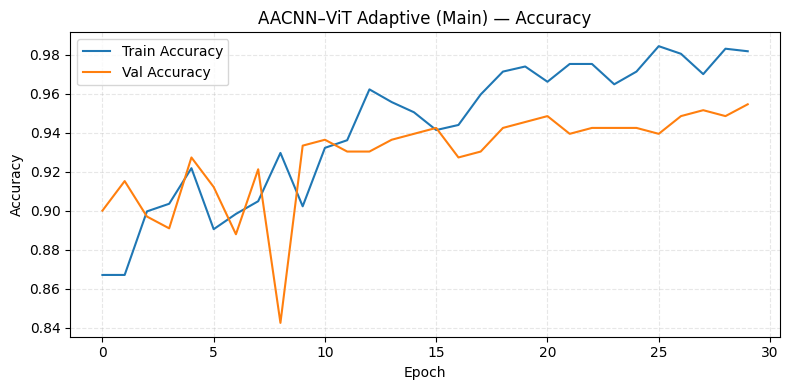

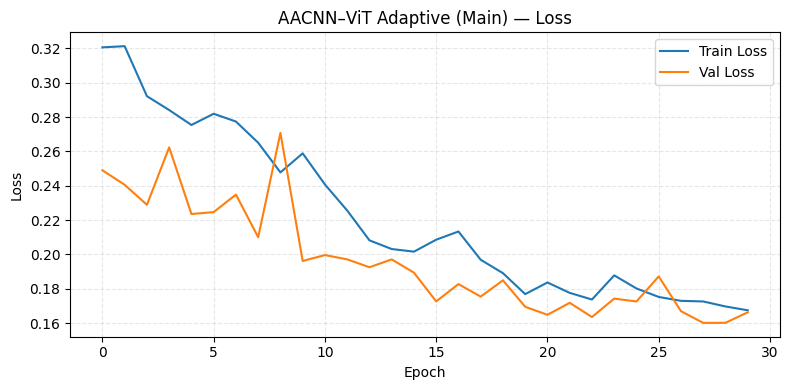

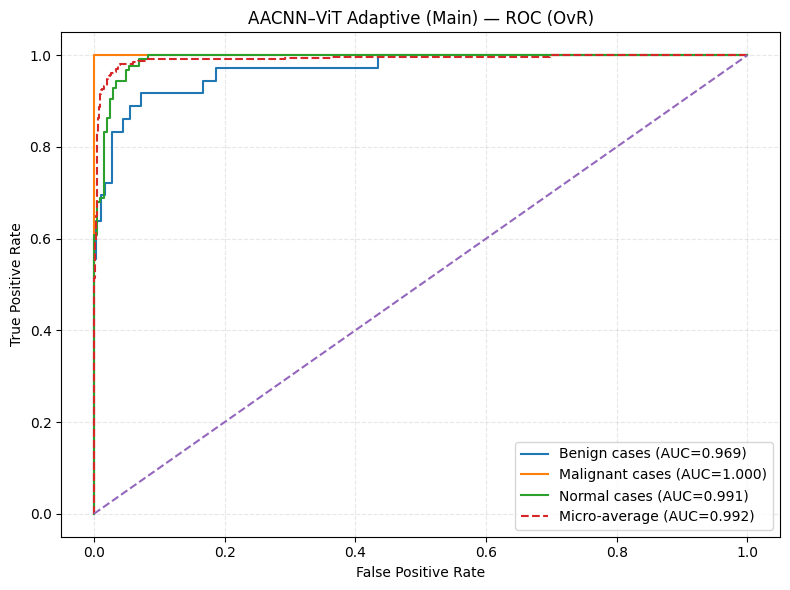

In [21]:
# MAIN (adaptive) – staged fine-tuning
try:
    aacnn_adapt, hist_aacnn_adapt = staged_train_and_plot(
        aacnn_adapt,
        train_seq=adapt_train,
        val_seq=fusion_val,
        class_weights=class_weights,
        epochs_a=EPOCHS_ADAPT_STAGE_A,
        epochs_b=EPOCHS_ADAPT_STAGE_B,
        unfreeze_last_n=UNFREEZE_LAST_N,
        title='AACNN–ViT Adaptive (Main)',
        ckpt_prefix="AACNN_ADAPT"
    )
except NameError as e:
    print(f"Error: {e}. Make sure the model and training helper are defined and ran earlier.")
    raise
except Exception as e:
    print(f"Training failed: {e}")
    raise

## Evaluation for all models

In [22]:
def eval_cnn(model, seq, class_names):
    y_true, y_pred = [], []
    for i in range(len(seq)):
        bx, by = seq[i]
        pr = model.predict(bx, verbose=0)
        y_true.append(np.argmax(by, axis=1))
        y_pred.append(np.argmax(pr, axis=1))
    y_true = np.concatenate(y_true); y_pred = np.concatenate(y_pred)
    print(confusion_matrix(y_true, y_pred))
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4, zero_division=0))

def eval_vit(model, seq, class_names):
    y_true, y_pred = [], []
    for i in range(len(seq)):
        bx, by = seq[i]
        pr = model.predict(bx, verbose=0)
        y_true.append(np.argmax(by, axis=1))
        y_pred.append(np.argmax(pr, axis=1))
    y_true = np.concatenate(y_true); y_pred = np.concatenate(y_pred)
    print(confusion_matrix(y_true, y_pred))
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4, zero_division=0))

def eval_fusion(model, seq, class_names):
    y_true, y_pred = [], []
    for i in range(len(seq)):
        (bx_img, bx_vit), by = seq[i]
        pr = model.predict([bx_img, bx_vit], verbose=0)
        y_true.append(np.argmax(by, axis=1))
        y_pred.append(np.argmax(pr, axis=1))
    y_true = np.concatenate(y_true); y_pred = np.concatenate(y_pred)
    print(confusion_matrix(y_true, y_pred))
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4, zero_division=0))

print("\n=== CNN ===")
eval_cnn(cnn_model, cnn_val, CLASS_DIRS)

print("\n=== ViT Head ===")
eval_vit(vit_model, vit_val, CLASS_DIRS)

print("\n=== CNN-ViT ===")
eval_fusion(cnnvit_model, fusion_val, CLASS_DIRS)


=== CNN ===


[[  0   0  36]
 [  0  94  75]
 [  0   0 125]]
                 precision    recall  f1-score   support

   Benign cases     0.0000    0.0000    0.0000        36
Malignant cases     1.0000    0.5562    0.7148       169
   Normal cases     0.5297    1.0000    0.6925       125

       accuracy                         0.6636       330
      macro avg     0.5099    0.5187    0.4691       330
   weighted avg     0.7128    0.6636    0.6284       330


=== ViT Head ===
[[  8   0  28]
 [  2 166   1]
 [  6   2 117]]
                 precision    recall  f1-score   support

   Benign cases     0.5000    0.2222    0.3077        36
Malignant cases     0.9881    0.9822    0.9852       169
   Normal cases     0.8014    0.9360    0.8635       125

       accuracy                         0.8818       330
      macro avg     0.7632    0.7135    0.7188       330
   weighted avg     0.8641    0.8818    0.8652       330


=== CNN-ViT ===
[[  3   0  33]
 [  1 164   4]
 [  2   3 120]]
                 precis

In [23]:
print("\n=== AACNN Adaptive ===")
eval_fusion(aacnn_adapt, fusion_val, CLASS_DIRS)

# print("\n=== AACNN No-Adaptive ===")
# eval_fusion(aacnn_noadapt, fusion_val, CLASS_DIRS)



=== AACNN Adaptive ===
[[ 25   0  11]
 [  0 169   0]
 [  4   0 121]]
                 precision    recall  f1-score   support

   Benign cases     0.8621    0.6944    0.7692        36
Malignant cases     1.0000    1.0000    1.0000       169
   Normal cases     0.9167    0.9680    0.9416       125

       accuracy                         0.9545       330
      macro avg     0.9262    0.8875    0.9036       330
   weighted avg     0.9534    0.9545    0.9527       330



## Plot

Epoch 1/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 375s 4s/step - accuracy: 0.7771 - loss: 0.2181 - val_accuracy: 0.7394 - val_loss: 0.2000
Epoch 2/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 359s 4s/step - accuracy: 0.7653 - loss: 0.2089 - val_accuracy: 0.6818 - val_loss: 0.2347
Epoch 3/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 224s 2s/step - accuracy: 0.7392 - loss: 0.2269 - val_accuracy: 0.6333 - val_loss: 0.2688
Epoch 4/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 113s 1s/step - accuracy: 0.7692 - loss: 0.2142 - val_accuracy: 0.8636 - val_loss: 0.1457
Epoch 5/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 188s 2s/step - accuracy: 0.7692 - loss: 0.2084 - val_accuracy: 0.7727 - val_loss: 0.1852
Epoch 6/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 231s 2s/step - accuracy: 0.7536 - loss: 0.2257 - val_accuracy: 0.6515 - val_loss: 0.2569
Epoch 7/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 311s 3s/step - accuracy: 0.7888 - loss: 0.2032 - val_accuracy: 0.7121 - val_loss: 0.2211
Epoch 8/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 419s 4s/step - accuracy: 0.7797 - loss: 0.1990 - val_accuracy: 0.7121 - v

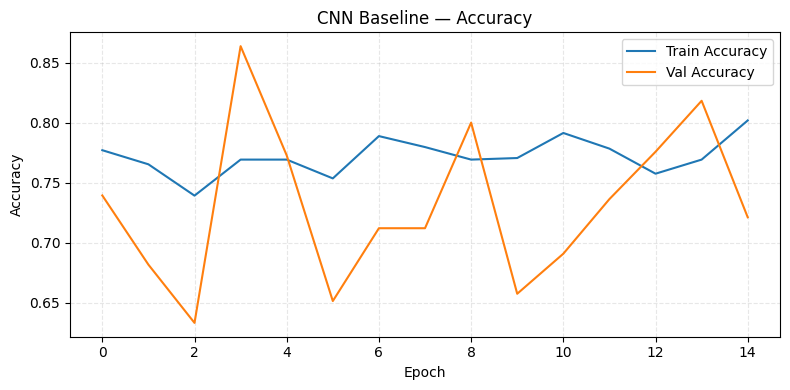

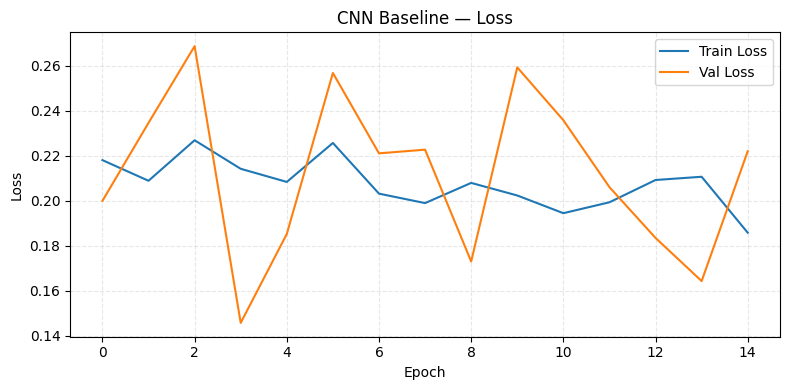

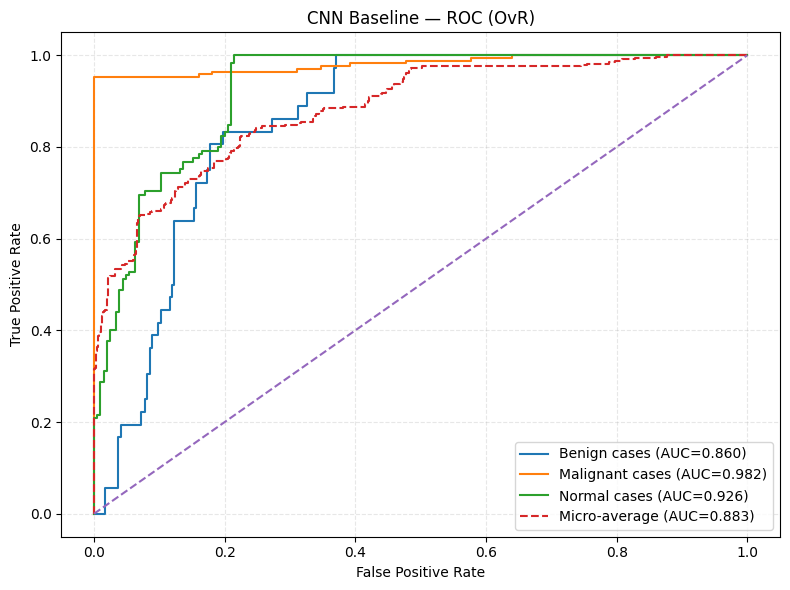

Epoch 1/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9074 - loss: 0.0857 - val_accuracy: 0.8788 - val_loss: 0.0829
Epoch 2/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9140 - loss: 0.0823 - val_accuracy: 0.8848 - val_loss: 0.0820
Epoch 3/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9074 - loss: 0.0824 - val_accuracy: 0.8848 - val_loss: 0.0789
Epoch 4/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9244 - loss: 0.0757 - val_accuracy: 0.9000 - val_loss: 0.0769
Epoch 5/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9218 - loss: 0.0755 - val_accuracy: 0.8939 - val_loss: 0.0754
Epoch 6/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9113 - loss: 0.0749 - val_accuracy: 0.8848 - val_loss: 0.0765
Epoch 7/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9309 - loss: 0.0721 - val_accuracy: 0.8909 - val_loss: 0.0778
Epoch 8/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9439 - loss: 0.0606 - val_accuracy: 0.8970 - val_loss:

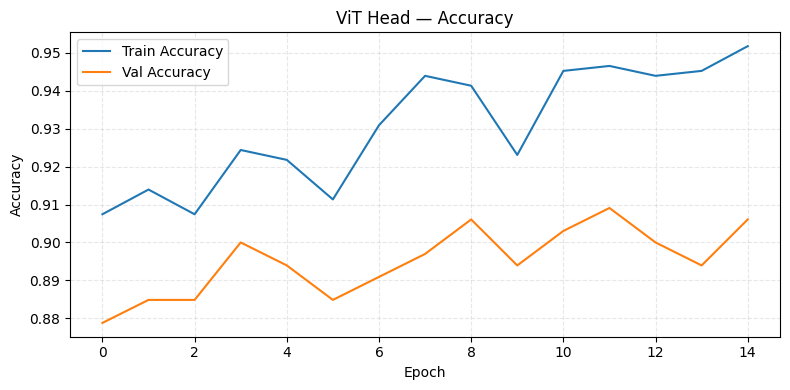

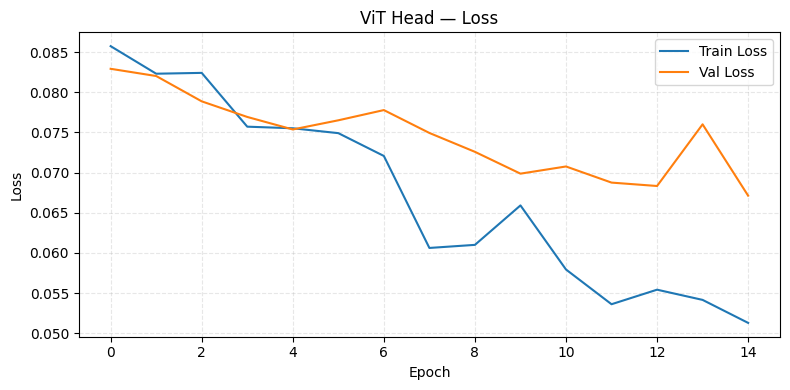

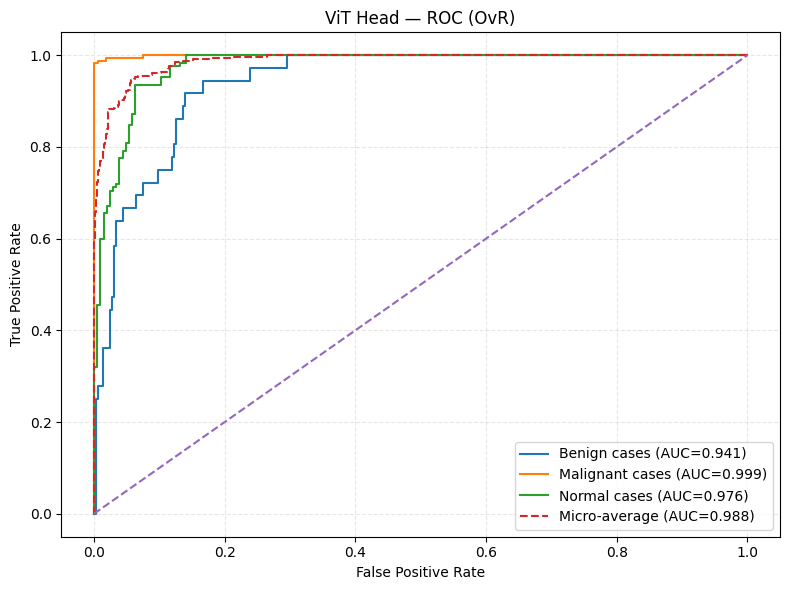

Epoch 1/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 184s 2s/step - accuracy: 0.9022 - loss: 0.0988 - val_accuracy: 0.8727 - val_loss: 0.0916
Epoch 2/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 61s 621ms/step - accuracy: 0.8905 - loss: 0.0933 - val_accuracy: 0.8758 - val_loss: 0.0909
Epoch 3/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 62s 645ms/step - accuracy: 0.9061 - loss: 0.0925 - val_accuracy: 0.8818 - val_loss: 0.0880
Epoch 4/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 67s 695ms/step - accuracy: 0.9179 - loss: 0.0856 - val_accuracy: 0.8788 - val_loss: 0.0885
Epoch 5/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 84s 716ms/step - accuracy: 0.9113 - loss: 0.0834 - val_accuracy: 0.8818 - val_loss: 0.0871
Epoch 6/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 64s 669ms/step - accuracy: 0.9192 - loss: 0.0873 - val_accuracy: 0.8818 - val_loss: 0.0846
Epoch 7/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 64s 663ms/step - accuracy: 0.9061 - loss: 0.0856 - val_accuracy: 0.8818 - val_loss: 0.0824
Epoch 8/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 61s 638ms/step - accuracy: 0.9140 - loss: 0.0808 - val_accura

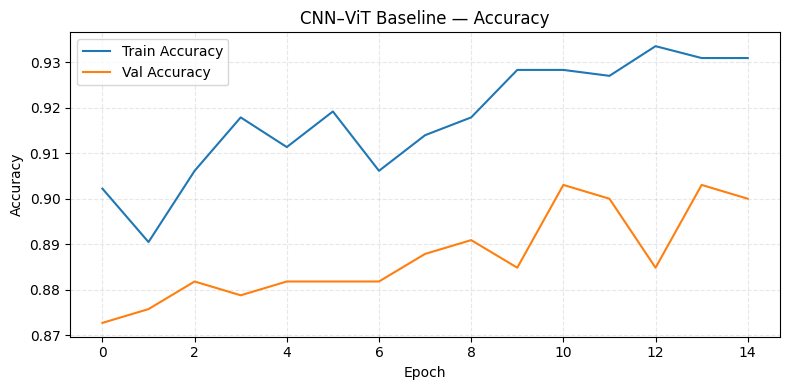

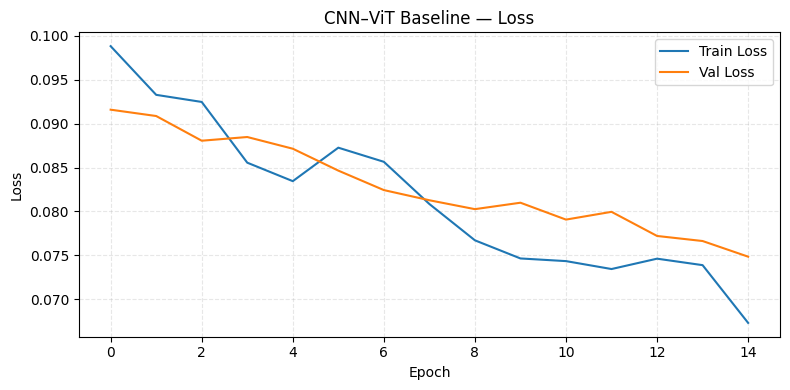

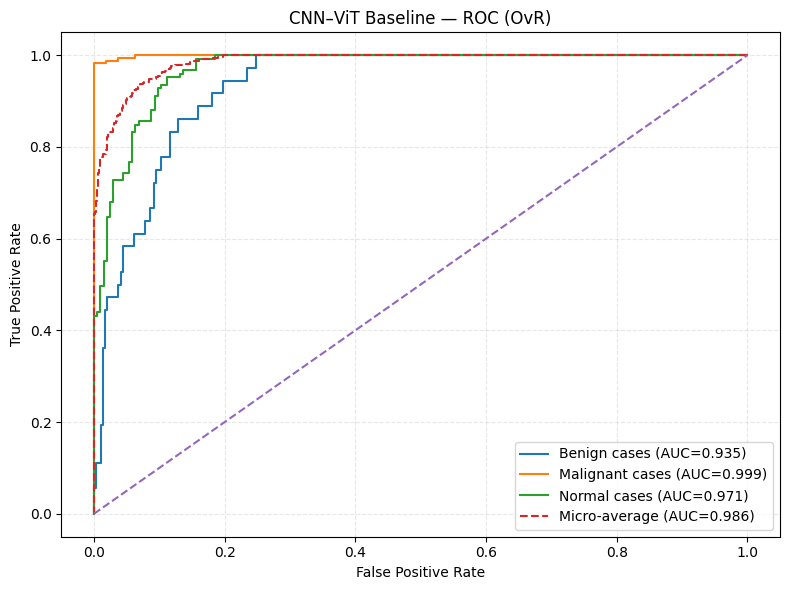

In [24]:
# 1) CNN
hist_cnn = train_and_plot_cnn(
    cnn_model, cnn_train, cnn_val,
    epochs=EPOCHS_CNN,
    class_weights=class_weights,
    title="CNN Baseline",
    lr=1e-4
)

# 2) ViT head (feature-only)
hist_vit = train_and_plot_vit(
    vit_model, vit_train, vit_val,
    epochs=EPOCHS_VIT,
    class_weights=class_weights,
    title="ViT Head",
    lr=1e-4
)

# 3) CNN–ViT baseline (fusion)
hist_cnnvit = train_and_plot_fusion(
    cnnvit_model, fusion_train, fusion_val,
    epochs=EPOCHS_CNNVIT,
    class_weights=class_weights,
    title="CNN–ViT Baseline",
    lr=1e-4
)

## Confusion Matrix Visualization

In [25]:
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support

def plot_conf_matrix_cnn(model, val_seq, title="Confusion Matrix"):
    """Generate confusion matrix for CNN-based models with detailed metrics."""
    y_true = []
    y_pred = []

    for i in range(len(val_seq)):
        bx, by = val_seq[i]
        preds = model.predict(bx, verbose=0)
        y_true.extend(np.argmax(by, axis=1))
        y_pred.extend(np.argmax(preds, axis=1))

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    cm = confusion_matrix(y_true, y_pred, labels=range(NUM_CLASSES))

    # Plot with detailed annotations
    plt.figure(figsize=(10, 8))
    ax = sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=CLASS_DIRS,
                yticklabels=CLASS_DIRS,
                cbar_kws={"label": "Count"},
                linewidths=1, linecolor='gray', 
                cbar=True, square=True)
    plt.xlabel("Predicted Label", fontsize=12, fontweight='bold')
    plt.ylabel("True Label", fontsize=12, fontweight='bold')
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
    
    # Print detailed metrics
    precision, recall, f1, support = precision_recall_fscore_support(y_true, y_pred, labels=range(NUM_CLASSES))
    accuracy = np.sum(np.diag(cm)) / np.sum(cm)
    
    print("\n" + "="*70)
    print("CONFUSION MATRIX & PERFORMANCE METRICS")
    print("="*70)
    print(f"\nOverall Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
    print("\nPer-Class Metrics:")
    print("-"*70)
    print(f"{'Class':<20} {'Precision':<15} {'Recall':<15} {'F1-Score':<15}")
    print("-"*70)
    for i, class_name in enumerate(CLASS_DIRS):
        print(f"{class_name:<20} {precision[i]:<15.4f} {recall[i]:<15.4f} {f1[i]:<15.4f}")
    print("="*70)

def plot_conf_matrix_fusion(model, val_seq, title="Confusion Matrix"):
    """Generate confusion matrix for fusion models with detailed metrics."""
    y_true = []
    y_pred = []

    for i in range(len(val_seq)):
        (bx_img, bx_vit), by = val_seq[i]
        preds = model.predict([bx_img, bx_vit], verbose=0)
        y_true.extend(np.argmax(by, axis=1))
        y_pred.extend(np.argmax(preds, axis=1))

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    cm = confusion_matrix(y_true, y_pred, labels=range(NUM_CLASSES))

    # Plot with detailed annotations
    plt.figure(figsize=(10, 8))
    ax = sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=CLASS_DIRS,
                yticklabels=CLASS_DIRS,
                cbar_kws={"label": "Count"},
                linewidths=1, linecolor='gray',
                cbar=True, square=True)
    plt.xlabel("Predicted Label", fontsize=12, fontweight='bold')
    plt.ylabel("True Label", fontsize=12, fontweight='bold')
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
    
    # Print detailed metrics
    precision, recall, f1, support = precision_recall_fscore_support(y_true, y_pred, labels=range(NUM_CLASSES))
    accuracy = np.sum(np.diag(cm)) / np.sum(cm)
    
    print("\n" + "="*70)
    print("CONFUSION MATRIX & PERFORMANCE METRICS")
    print("="*70)
    print(f"\nOverall Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
    print("\nPer-Class Metrics:")
    print("-"*70)
    print(f"{'Class':<20} {'Precision':<15} {'Recall':<15} {'F1-Score':<15}")
    print("-"*70)
    for i, class_name in enumerate(CLASS_DIRS):
        print(f"{class_name:<20} {precision[i]:<15.4f} {recall[i]:<15.4f} {f1[i]:<15.4f}")
    print("="*70)

## ROC Curve + AUC

In [26]:
def plot_roc_curves_cnn(model, val_seq, title="ROC Curves"):
    """Generate ROC curves for CNN-based models with AUC scores."""
    y_true = []
    y_probs = []

    for i in range(len(val_seq)):
        bx, by = val_seq[i]
        preds = model.predict(bx, verbose=0)
        y_true.extend(np.argmax(by, axis=1))
        y_probs.extend(preds)

    y_true = np.array(y_true)
    y_probs = np.array(y_probs)
    y_true_bin = label_binarize(y_true, classes=range(NUM_CLASSES))

    plt.figure(figsize=(10, 8))
    
    auc_scores = []
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
    
    for i in range(NUM_CLASSES):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
        roc_auc = auc(fpr, tpr)
        auc_scores.append(roc_auc)
        plt.plot(fpr, tpr, linewidth=2.5, label=f'{CLASS_DIRS[i]} (AUC = {roc_auc:.4f})', 
                marker='o', markersize=4, color=colors[i], alpha=0.8)

    plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random Classifier (AUC = 0.5000)', alpha=0.6)
    plt.xlim([-0.02, 1.02])
    plt.ylim([-0.02, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
    plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
    plt.title(title, fontsize=14, fontweight='bold')
    plt.legend(loc="lower right", fontsize=11, framealpha=0.95)
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Print AUC summary
    print("\n" + "="*50)
    print("ROC-AUC SUMMARY")
    print("="*50)
    mean_auc = np.mean(auc_scores)
    print(f"Mean AUC: {mean_auc:.4f}")
    for i, class_name in enumerate(CLASS_DIRS):
        status = "✓" if auc_scores[i] > 0.8 else "◐" if auc_scores[i] > 0.7 else "✗"
        print(f"  {status} {class_name}: {auc_scores[i]:.4f}")
    print("="*50)

def plot_roc_curves_fusion(model, val_seq, title="ROC Curves"):
    """Generate ROC curves for fusion models with AUC scores."""
    y_true = []
    y_probs = []

    for i in range(len(val_seq)):
        (bx_img, bx_vit), by = val_seq[i]
        preds = model.predict([bx_img, bx_vit], verbose=0)
        y_true.extend(np.argmax(by, axis=1))
        y_probs.extend(preds)

    y_true = np.array(y_true)
    y_probs = np.array(y_probs)
    y_true_bin = label_binarize(y_true, classes=range(NUM_CLASSES))

    plt.figure(figsize=(10, 8))
    
    auc_scores = []
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
    
    for i in range(NUM_CLASSES):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
        roc_auc = auc(fpr, tpr)
        auc_scores.append(roc_auc)
        plt.plot(fpr, tpr, linewidth=2.5, label=f'{CLASS_DIRS[i]} (AUC = {roc_auc:.4f})', 
                marker='o', markersize=4, color=colors[i], alpha=0.8)

    plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random Classifier (AUC = 0.5000)', alpha=0.6)
    plt.xlim([-0.02, 1.02])
    plt.ylim([-0.02, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
    plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
    plt.title(title, fontsize=14, fontweight='bold')
    plt.legend(loc="lower right", fontsize=11, framealpha=0.95)
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Print AUC summary
    print("\n" + "="*50)
    print("ROC-AUC SUMMARY")
    print("="*50)
    mean_auc = np.mean(auc_scores)
    print(f"Mean AUC: {mean_auc:.4f}")
    for i, class_name in enumerate(CLASS_DIRS):
        status = "✓" if auc_scores[i] > 0.8 else "◐" if auc_scores[i] > 0.7 else "✗"
        print(f"  {status} {class_name}: {auc_scores[i]:.4f}")
    print("="*50)

## Model Evaluation Examples

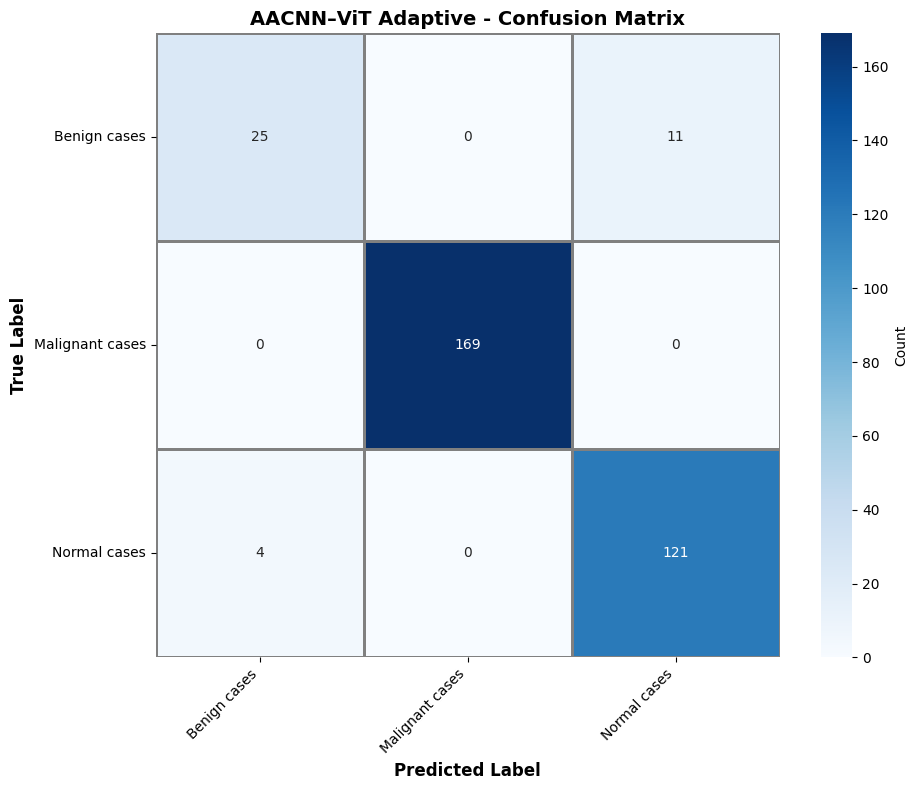


CONFUSION MATRIX & PERFORMANCE METRICS

Overall Accuracy: 0.9545 (95.45%)

Per-Class Metrics:
----------------------------------------------------------------------
Class                Precision       Recall          F1-Score       
----------------------------------------------------------------------
Benign cases         0.8621          0.6944          0.7692         
Malignant cases      1.0000          1.0000          1.0000         
Normal cases         0.9167          0.9680          0.9416         


In [27]:
# Confusion Matrix for AACNN Adaptive
plot_conf_matrix_fusion(aacnn_adapt, fusion_val, title="AACNN–ViT Adaptive - Confusion Matrix")

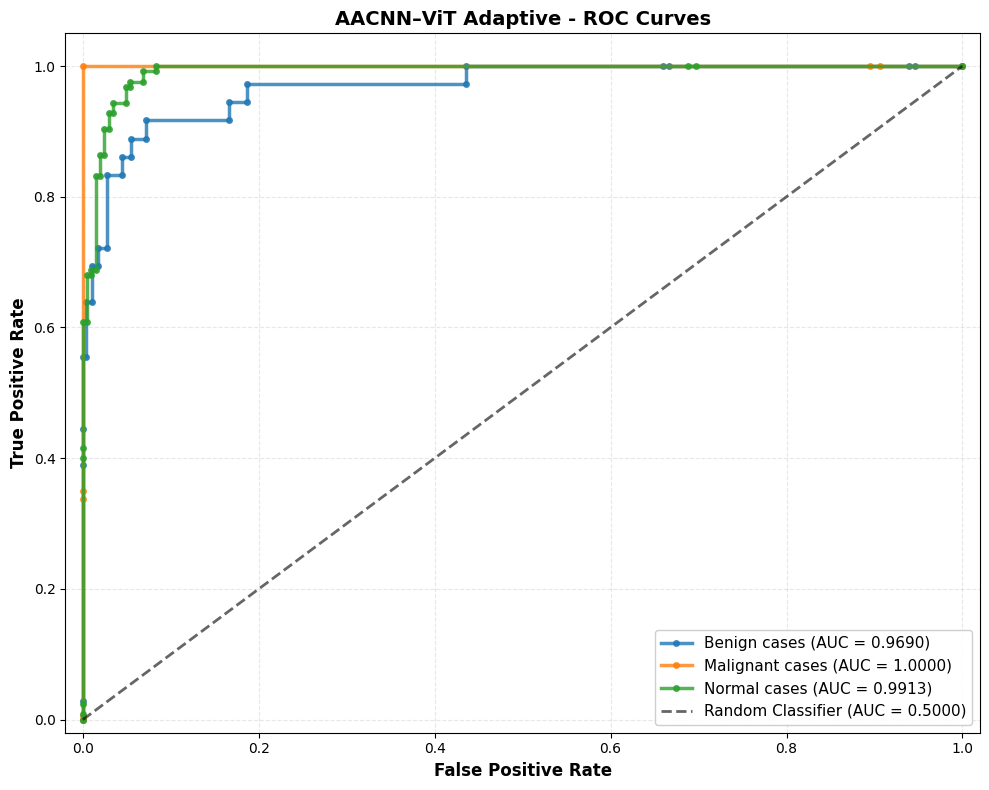


ROC-AUC SUMMARY
Mean AUC: 0.9868
  ✓ Benign cases: 0.9690
  ✓ Malignant cases: 1.0000
  ✓ Normal cases: 0.9913


In [28]:
# ROC Curves for AACNN Adaptive
plot_roc_curves_fusion(aacnn_adapt, fusion_val, title="AACNN–ViT Adaptive - ROC Curves")

## Single Image Prediction & Risk Assessment

In [31]:
def predict_single_image(image_path, model, vit_features_path, image_idx):
    """
    Predict on a single image using AACNN Adaptive model.
    Generates comprehensive diagnostic report with confidence assessment.
    """
    # Load and prepare image
    img = load_img_01(image_path)
    img_input = np.expand_dims(img, axis=0)  # [1, H, W, 3]
    
    # Load ViT features
    vit_feats = np.load(vit_features_path, allow_pickle=True)
    vit_input = np.expand_dims(vit_feats[image_idx], axis=0)  # [1, 768]
    
    # Predict
    pred = model.predict([img_input, vit_input], verbose=0)
    prob = np.max(pred)
    class_idx = np.argmax(pred)
    risk_info = get_risk_level(prob)
    
    # Generate comprehensive report
    print("\n" + "="*80)
    print(" "*25 + "DIAGNOSTIC PREDICTION REPORT")
    print("="*80)
    
    print(f"\nImage File: {os.path.basename(image_path)}")
    
    print(f"\n[PRIMARY DIAGNOSIS]")
    print(f"  ► Predicted Class: {CLASS_DIRS[class_idx]}")
    print(f"  ► Confidence Score: {prob:.4f} ({prob*100:.2f}%)")
    
    print(f"\n[CONFIDENCE ASSESSMENT]")
    print(f"  ► Level: {risk_info['level']} [{risk_info['code']}]")
    print(f"  ► Status: {risk_info['description']}")
    
    print(f"\n[CLASS PROBABILITY DISTRIBUTION]")
    
    # Sort by probability for better visualization
    sorted_indices = np.argsort(pred[0])[::-1]
    for rank, idx in enumerate(sorted_indices, 1):
        class_prob = pred[0, idx]
        bar_length = int(class_prob * 50)
        bar = "█" * bar_length + "░" * (50 - bar_length)
        confidence = "HIGH" if class_prob > 0.7 else "MODERATE" if class_prob > 0.4 else "LOW"
        marker = "★" if idx == class_idx else "○"
        print(f"  {marker} {rank}. {CLASS_DIRS[idx]:<18} {class_prob:.4f} ({class_prob*100:5.2f}%) {bar} [{confidence}]")
    
    print("\n" + "="*80 + "\n")
    
    return pred, prob, class_idx
test_image_path = r"C:\Users\Bilal\OneDrive\Desktop\Lung Cancer\AACNN-ViT\datasets\Malignant cases\Malignant case (561).jpg"

pred, prob, class_idx = predict_single_image(
    test_image_path,
    aacnn_adapt,        # your trained model
    VAL_FEATURES_PATH,  # path to ViT features
    0
    )


                         DIAGNOSTIC PREDICTION REPORT

Image File: Malignant case (561).jpg

[PRIMARY DIAGNOSIS]
  ► Predicted Class: Malignant cases
  ► Confidence Score: 0.9853 (98.53%)

[CONFIDENCE ASSESSMENT]
  ► Level: CRITICAL CONFIDENCE [C]
  ► Status: Exceptional confidence - Highly reliable diagnosis

[CLASS PROBABILITY DISTRIBUTION]
  ★ 1. Malignant cases    0.9853 (98.53%) █████████████████████████████████████████████████░ [HIGH]
  ○ 2. Normal cases       0.0118 ( 1.18%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░ [LOW]
  ○ 3. Benign cases       0.0028 ( 0.28%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░ [LOW]




## Grad-CAM Visualization (⚠️ CNN Model Only)

**Important Note**: Grad-CAM visualization works **only on the CNN branch** of fusion models. For the AACNN–ViT Adaptive model, use the CNN baseline model for explainability instead.

### Expected Layers:
- **CNN Baseline**: Use `last_conv` layer (Conv2D at shape (16, 16, 128))
- **AACNN Adaptive**: Grad-CAM requires architectural modification for fusion models

Generating Grad-CAM visualization for: Malignant case (561).jpg
This visualization shows which regions of the image the model focuses on.



c:\Users\Bilal\OneDrive\Desktop\Lung Cancer\.venv\Lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor']]
Received: inputs=Tensor(shape=(1, 512, 512, 3))
  warnings.warn(msg)


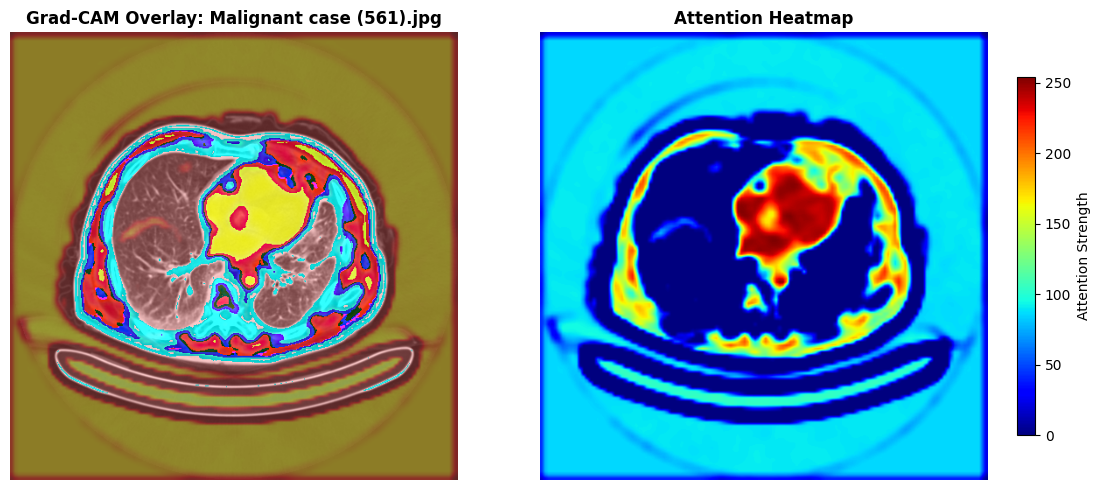

✓ Grad-CAM visualization generated for: Malignant case (561).jpg


In [33]:
# Display Grad-CAM visualization for CNN model (best for explainability)
# Note: Grad-CAM only works well with single-input CNN models
# For AACNN fusion models, use CNN_Baseline instead

try:
    test_image_path = r"C:\Users\Bilal\OneDrive\Desktop\Lung Cancer\AACNN-ViT\datasets\Malignant cases\Malignant case (561).jpg"
    
    print(f"Generating Grad-CAM visualization for: {os.path.basename(test_image_path)}")
    print("This visualization shows which regions of the image the model focuses on.\n")
    display_gradcam(test_image_path, cnn_model)
    
except Exception as e:
    print(f"Note: Grad-CAM requires proper model setup. Error: {str(e)}")
    print("\nTo enable Grad-CAM:")
    print("  1. Ensure CNN model has 'last_conv' layer defined")
    print("  2. Use CNN_Baseline model (not fusion models)")
    print("  3. Check that image loading works correctly")

# Examples for other images:
# display_gradcam(X_val[1], cnn_model)  # Second validation image
# display_gradcam(X_val[5], cnn_model)  # Sixth validation image

In [1]:
import zipfile
import tensorflow as tf
import keras
import os
import shutil

keras_path = r"C:\Users\Bilal\OneDrive\Desktop\Lung Cancer\AACNN-ViT\aacnn_vit_model.keras"
extract_dir = r"C:\Users\Bilal\OneDrive\Desktop\Lung Cancer\AACNN-ViT\temp_model"

shutil.rmtree(extract_dir, ignore_errors=True)
os.makedirs(extract_dir)

with zipfile.ZipFile(keras_path, 'r') as z:
    z.extractall(extract_dir)

print("Model extracted")

weights_path = os.path.join(extract_dir, "model.weights.h5")
print("Weights located at:", weights_path)

Model extracted
Weights located at: C:\Users\Bilal\OneDrive\Desktop\Lung Cancer\AACNN-ViT\temp_model\model.weights.h5


In [ ]:
aacnn_adapt.save("aacnn_vit_model.keras")
print("Model saved successfully.")

Model saved successfully.


: 